In [2]:
import pysheds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import fiona
import xarray as xr
import shapefile
import math
from scipy import stats
import os
from numpy import random
import netCDF4 as nc
from netCDF4 import Dataset
from shapely.geometry import Point, shape, box, mapping, Polygon, MultiPolygon
from shapely.vectorized import contains
from shapely.strtree import STRtree
import matplotlib.path as mpath
from scipy.ndimage import sobel
from rasterio.transform import rowcol
from rasterio.coords import BoundingBox
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.features import shapes

In [3]:
def get_stationdata(station_file):
  # Remove spaces in column names entirely
  df_Q = pd.read_csv(station_file, delimiter=';',encoding='utf-8',skiprows=38)
  # print(df_Q.head)

  df_Q.columns = df_Q.columns.str.replace(' ', '')
  df_Q['YYYY-MM-DD'] = df_Q['YYYY-MM-DD'].str.slice(0, 7)

  # Convert 'YYYY-MM-DD' column to datetime format
  df_Q['YYYY-MM-DD'] = pd.to_datetime(df_Q['YYYY-MM-DD'], format='%Y-%m')

  # Convert cutoff_date to datetime format
  start_date = pd.to_datetime('2018-08', format='%Y-%m')
  end_date = pd.to_datetime('2025-11', format='%Y-%m')

  # Filter the DataFrame to keep rows after '2018-08'
  df_filtered = df_Q[df_Q['YYYY-MM-DD'] >= start_date]
  df_filtered = df_filtered[df_filtered['YYYY-MM-DD'] <= end_date]

  # print(df_filtered.head)

  stream_gauge = df_filtered['Calculated'].values
  # print(len(stream_gauge))

  df_filtered['YYYY-MM-DD'] = df_filtered['YYYY-MM-DD'].dt.strftime('%Y-%m')
  dates = df_filtered['YYYY-MM-DD']
  dates = dates.reset_index()
  # print(dates)

  return stream_gauge, dates

In [4]:
def waterpx_count(shp_input, nc_input):

  # Open NetCDF file and extract variables
  with nc.Dataset(nc_input) as dataset:
      watermask = dataset.variables['watermask'][:]
      latitude = dataset.variables['lat'][:]
      longitude = dataset.variables['lon'][:]

  # Load and reproject the shapefile
  shp = gpd.read_file(shp_input).to_crs('EPSG:4326')
  minlon, minlat, maxlon, maxlat = shp.geometry.total_bounds

  # Limit the NetCDF data to the bounding box of the shapefile
  lat_mask = (latitude >= minlat) & (latitude <= maxlat)
  lon_mask = (longitude >= minlon) & (longitude <= maxlon)

  watermask = watermask[lat_mask, :][:, lon_mask]
  lat_filtered = latitude[lat_mask]
  lon_filtered = longitude[lon_mask]

  # Step 1: Create a grid of filtered points
  lon_grid, lat_grid = np.meshgrid(lon_filtered, lat_filtered)
  points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])

  # Flatten the watermask array to align with points
  watermask_flat = watermask.ravel()

  # Step 2: Load the shapefile and get combined geometry
  shapefile_geom = shp.geometry.unary_union  # Combine all geometries in the shapefile

  # Step 3: Identify points intersecting the shapefile
  intersects_mask = contains(shapefile_geom, points[:, 0], points[:, 1])

  # Step 4: Filter the points and watermask values
  filtered_points = points[intersects_mask]
  filtered_watermask = watermask_flat[intersects_mask]

  # Step 5: Create geometries for intersecting points
  geometries = [Point(lon, lat) for lon, lat in filtered_points]

  # Step 6: Create a GeoDataFrame
  gdf = gpd.GeoDataFrame({'watermask': filtered_watermask}, geometry=geometries, crs='EPSG:4326')


  # markercolormap2= colors.ListedColormap(['white', 'black','blue'])

  # # Assuming gdf and water_percent are defined, and markercolormap2 is valid
  # fig, ax = plt.subplots(1, 1, figsize=(10, 8))
  # gdf.plot(column='watermask', ax=ax, vmin=0, vmax=3, legend=True, markersize=5, cmap=markercolormap2)
  # ax.set_title(nc_input)
  # ax.set_xlabel('Longitude')
  # ax.set_ylabel('Latitude')
  # plt.show()

  # Step 1: Filter the GeoDataFrame where 'watermask' is equal to 2
  filtered_gdf = gdf[gdf['watermask'] == 1]

  water_pixels = len(filtered_gdf)
  total_pixels = len(gdf)

  water_percent = (water_pixels / total_pixels) * 100

  return water_pixels, water_percent, total_pixels

In [5]:
def calc_avg_precip(shp_input, date_input):
    precip_folder = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/PRECIP/RESAMPLED/'
    filename = f"IMERG-Final.CLIM.2001-2022.{date_input}.V07B.nc4"
    
    nc_input = os.path.join(precip_folder, filename)
    
    # Open NetCDF file and extract variables
    with nc.Dataset(nc_input) as dataset:
        precip = dataset.variables['precipitation'][:]  # shape (time, lat, lon) or (lat, lon)
        # print(precip.shape)
        latitude = dataset.variables['lat'][:]  # shape (lat,)
        longitude = dataset.variables['lon'][:]  # shape (lon,)
    
    # Load and reproject the shapefile
    shp = gpd.read_file(shp_input).to_crs('EPSG:4326')
    minlon, minlat, maxlon, maxlat = shp.geometry.total_bounds
    
    # Limit the NetCDF data to the bounding box of the shapefile
    lat_mask = (latitude >= minlat) & (latitude <= maxlat)
    lon_mask = (longitude >= minlon) & (longitude <= maxlon)
    
    # Filter latitude and longitude based on the mask
    lat_filtered = latitude[lat_mask]
    lon_filtered = longitude[lon_mask]
    # print(lat_filtered,lon_filtered)
    
    # Step 1: Create a grid of filtered points
    lon_grid, lat_grid = np.meshgrid(lon_filtered, lat_filtered)
    points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    
    # Check the dimensionality of precip
    if precip.ndim == 2:  # If it's (lat, lon)
        precip_filtered = precip[:,lat_mask][lon_mask,:]  # Apply both lat and lon masks
    elif precip.ndim == 3:  # If it's (time, lat, lon)
        precip_filtered = precip[:, lat_mask, :][:, :, lon_mask]
    
    # Flatten the filtered precipitation array (time dimension included if 3D)
    precip_flat = precip_filtered.ravel()
    
    # Step 2: Load the shapefile and get combined geometry
    shapefile_geom = shp.geometry.unary_union  # Combine all geometries in the shapefile
    
    # Step 3: Identify points intersecting the shapefile
    intersects_mask = contains(shapefile_geom, points[:, 0], points[:, 1])
    
    # Step 4: Filter the points and precipitation values
    filtered_points = points[intersects_mask]
    filtered_precip = precip_flat[intersects_mask]
    
    avg = np.mean(filtered_precip)

    return avg

In [33]:
masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_UPDATED.csv'
# final_path = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS__DAILY_FINAL_2_00.csv'

stations_df = pd.read_csv(masterlist)
# print(stations_df)
station_num = stations_df['grdc_no']
# station_num

final_result = pd.DataFrame()
print(f"Loaded {len(station_num)} stations.") # as of Nov 2025: should be 578 stations total when loading all

import warnings
warnings.filterwarnings("ignore")

for s in range(111,112):
    
    station = station_num[s]
    print("Running station ", station)
    
    data = stations_df.iloc[s]

    number = station
    region = data['wmo_reg']
    river = data['river']
    name = data['station']
    lat = data['lat']
    lon = data['long']
    area = data['area_delin']
    altitude = data['altitude']
    
    q_file = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/STATIONS/{number}_Q_Month.txt'
    shp_file = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/{station}/{station}.shp' # all station delineated shapefiles saved in subfolders named by station number
    dem_file = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/DEM/STATIONS/{station}_dem.tif' # cropped .tif files for 15 arc-second DEM saved in subfolders named by station number
    
    results_df = pd.DataFrame(stations_df.iloc[[s]])
    stream_gauge, dates = get_stationdata(q_file)

    #directory = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/"
    #file_list = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

    # Calculate water pixel count
    ncdf_list = []
    water_px = np.zeros(len(dates))
    water_pcnt = np.zeros(len(dates)) 
    water_area = np.zeros(len(dates))
    tot_px = np.zeros(len(dates))

    for i in range(0,len(dates)):
        date = dates['YYYY-MM-DD'][i]
        ncdf_name = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.{date}.l3.uc-berkeley-watermask-monthly.a31.d32.nc'
        ncdf_list.append(ncdf_name)
    for f, filename in enumerate(ncdf_list):
#        print(filename)
        if os.path.isfile(filename):
            print(filename)
            pixel_count, pixel_percent, total_pixels = waterpx_count(shp_file, filename)
            water_px[f] = pixel_count
            water_pcnt[f] = pixel_percent
            tot_px[f] = total_pixels
            water_area[f] = ((pixel_percent*area)/100)


Loaded 578 stations.
Running station  1357600
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2018-08.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2018-09.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2018-10.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2018-11.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2018-12.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WATERMASK/cyg.ddmi.2019-01.l3.uc-berkeley-watermask-monthly.a31.d32.nc
/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/MONTHLY_WAT

In [35]:
df_final = pd.DataFrame({'Date': dates['YYYY-MM-DD'], 'Q': stream_gauge,'SWE': water_pcnt, 'SWE_scaled': water_area, 'P': precip})
df_final

,Date,Q,SWE,SWE_scaled,P
0,2018-08,-999.0,0.870262,86.985231,0.013451
1,2018-09,-999.0,0.652697,65.238923,0.191437
2,2018-10,-999.0,0.652697,65.238923,0.722636
3,2018-11,-999.0,0.435131,43.492615,2.073935
4,2018-12,-999.0,0.458033,45.781700,2.517518
5,2019-01,-999.0,0.687049,68.672550,2.948344
6,2019-02,-999.0,0.446582,44.637158,2.664697
7,2019-03,-999.0,0.526738,52.648955,1.551684
8,2019-04,-999.0,0.583992,58.371668,0.970026
9,2019-05,-999.0,0.606893,60.660753,0.088911


In [7]:
precip = np.zeros(len(dates))
date_inputs = dates['YYYY-MM-DD']
for index, date in enumerate(date_inputs):
    date_input = date[-2:]
    # Compute average precipitation for this date and shapefile
    precip[index] = calc_avg_precip(shp_file, date_input)

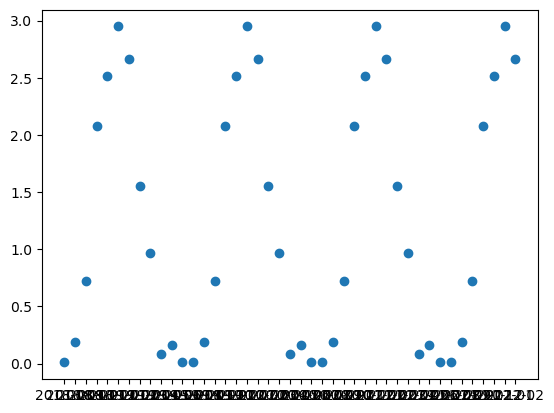

In [16]:
plt.scatter(date_inputs, precip)

In [11]:
pixel_count, pixel_percent, total_pixels

NameError: name 'pixel_count' is not defined

In [69]:
import os

directory = "/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_DAILY_WATERMASK/"

# Loop over all files in the directory and remove them
for filename in os.listdir(directory):
    file_path = os.path.join(directory, filename)
    if os.path.isfile(file_path):  # Only delete files, not subdirectories
        os.remove(file_path)

print("All files deleted in", directory)


All files deleted in /global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_DAILY_WATERMASK/
